In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.integrate import quad

Weibull-fit Hs                        : a = 0.8023, b = 1.7312
Aantal sluitingen per jaar (n_events) : 3.30
Kansmassa binnen [0.0, 6.0] m       : 1.000000
Totale stormduur per jaar             : 115.5 uur
Totale stormduur over levensduur      : 11550 uur
Regressie Tp = 1.9192*Hs + 5.5894   (R^2 = 0.9119)

Totaal aantal golfcycli over levensduur: 7.745e+06

Miner-schade per golfhoogteblok (bin = 0.10 m):
 H_mid (m)  n_i (-)  dSigma_i (MPa)    N_R,i (-)  D_i (-)
      0.55 484908.0           38.75 4.070614e+07   0.0119
      0.65 383941.0           45.80 1.765658e+07   0.0217
      0.75 428856.0           52.84 8.633106e+06   0.0497
      0.85 210791.0           59.89 4.766672e+06   0.0442
      0.95 165228.0           66.94 3.414296e+06   0.0484
      1.05 183060.0           73.98 2.528740e+06   0.0724
      1.15  89478.0           81.03 1.924769e+06   0.0465
      1.25  69940.0           88.07 1.498794e+06   0.0467
      1.35  77318.0           95.12 1.189791e+06   0.0650
      1.45  3

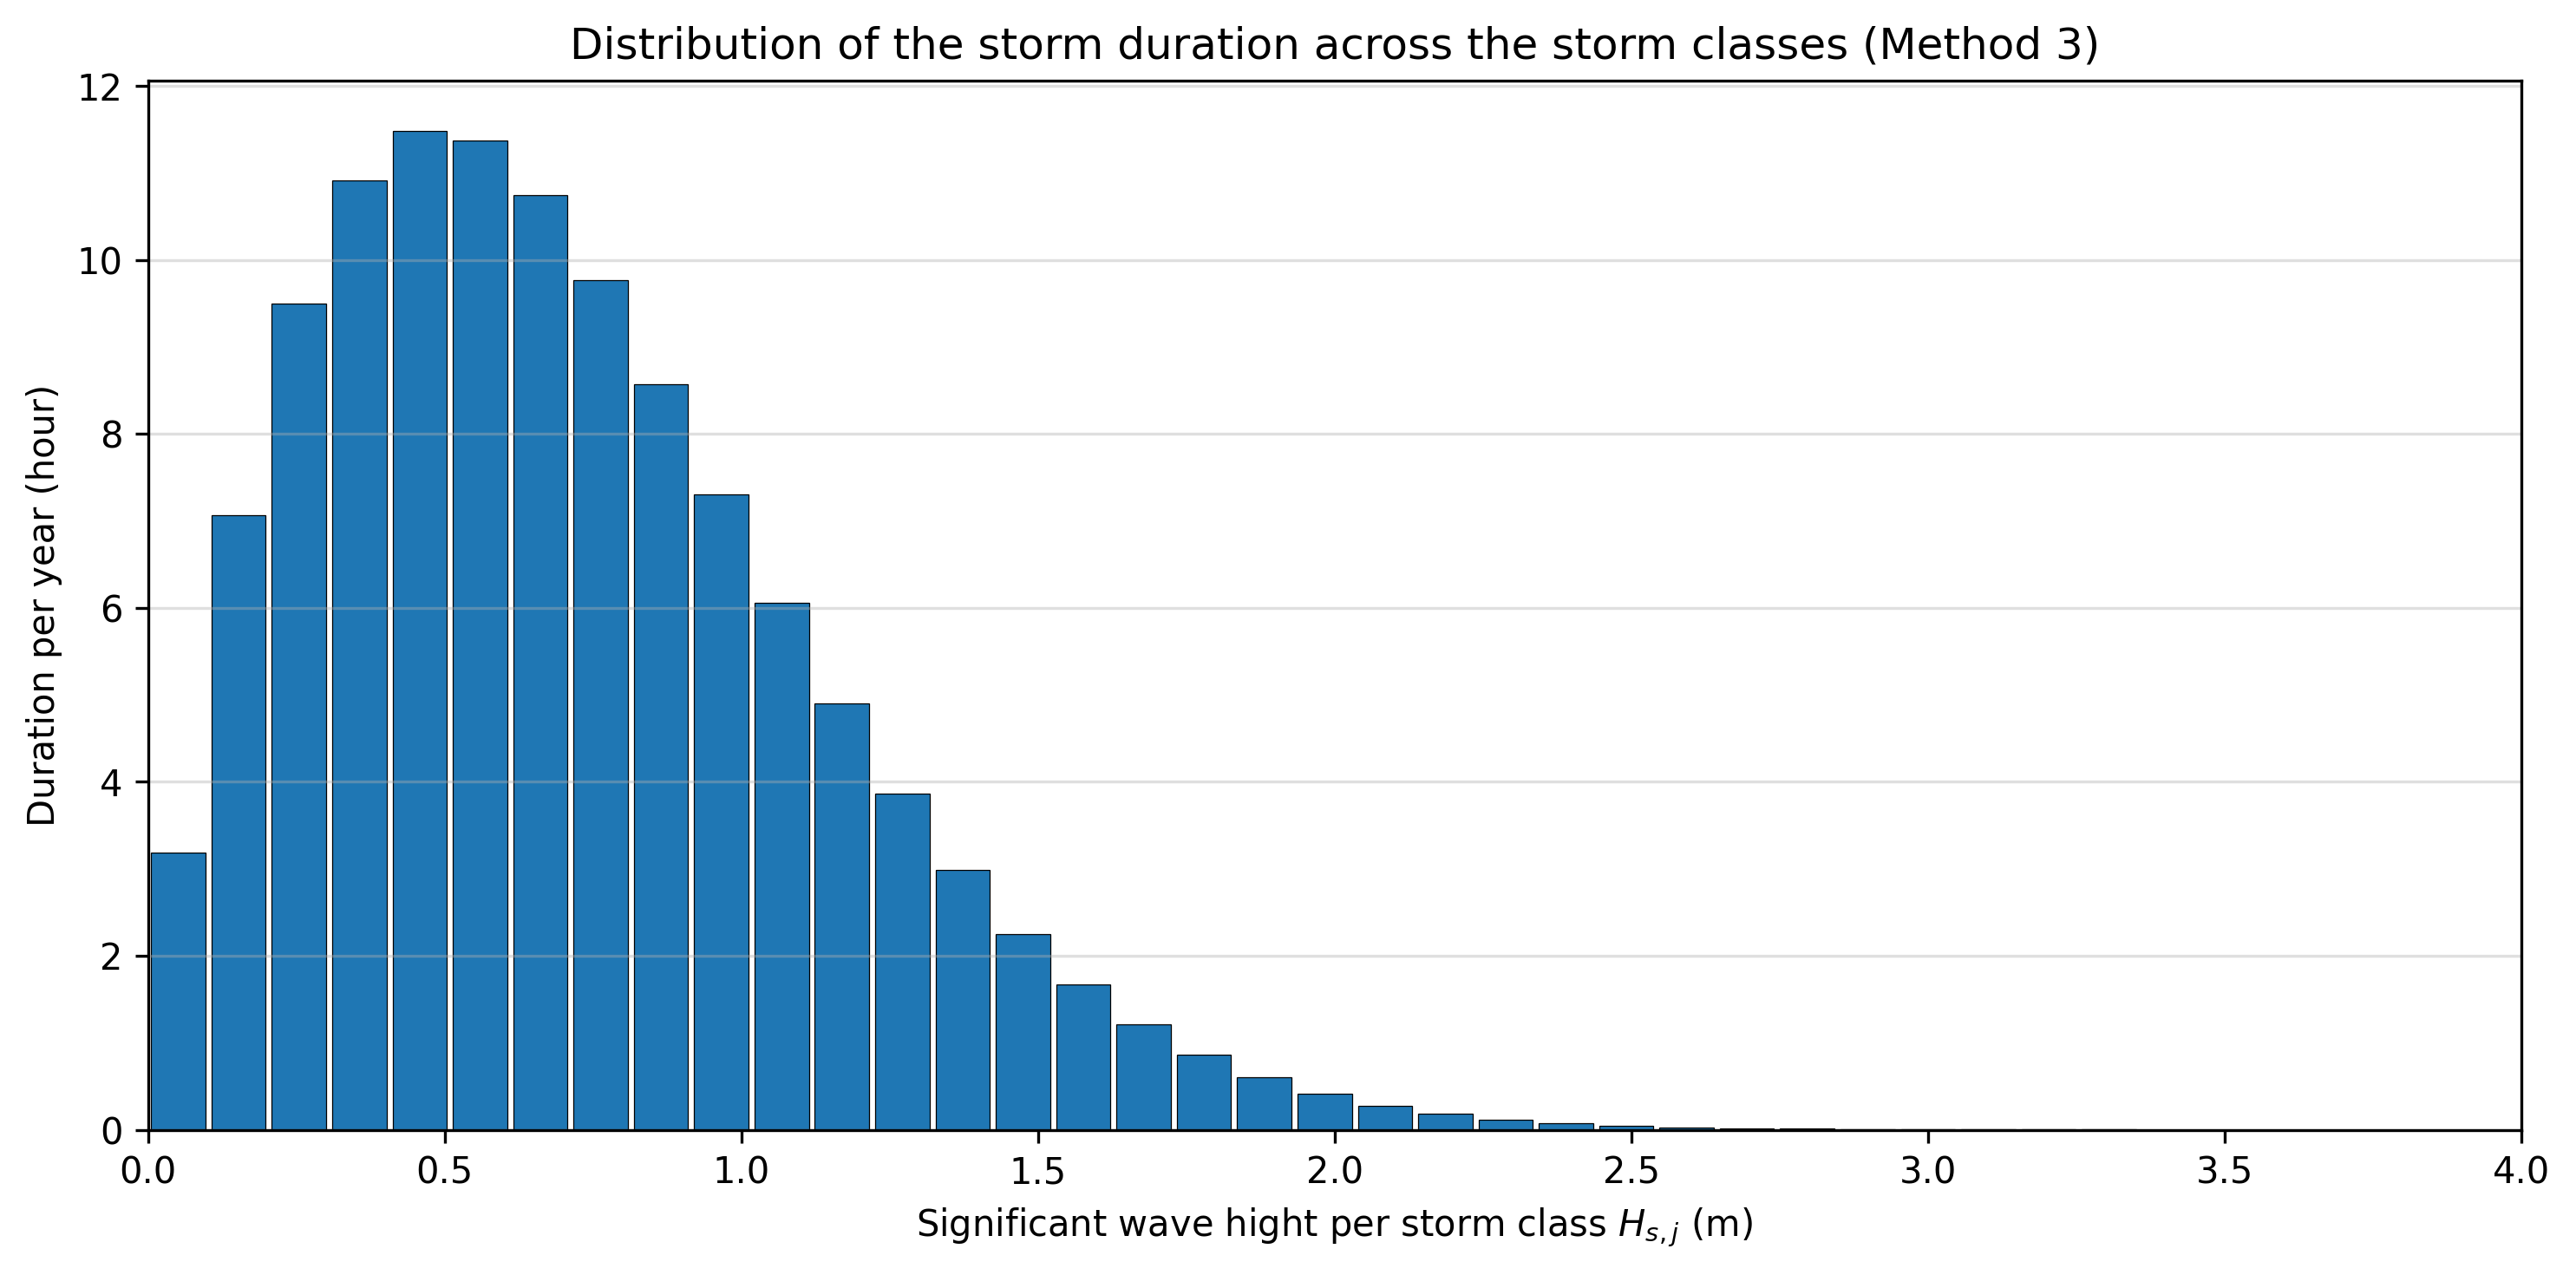

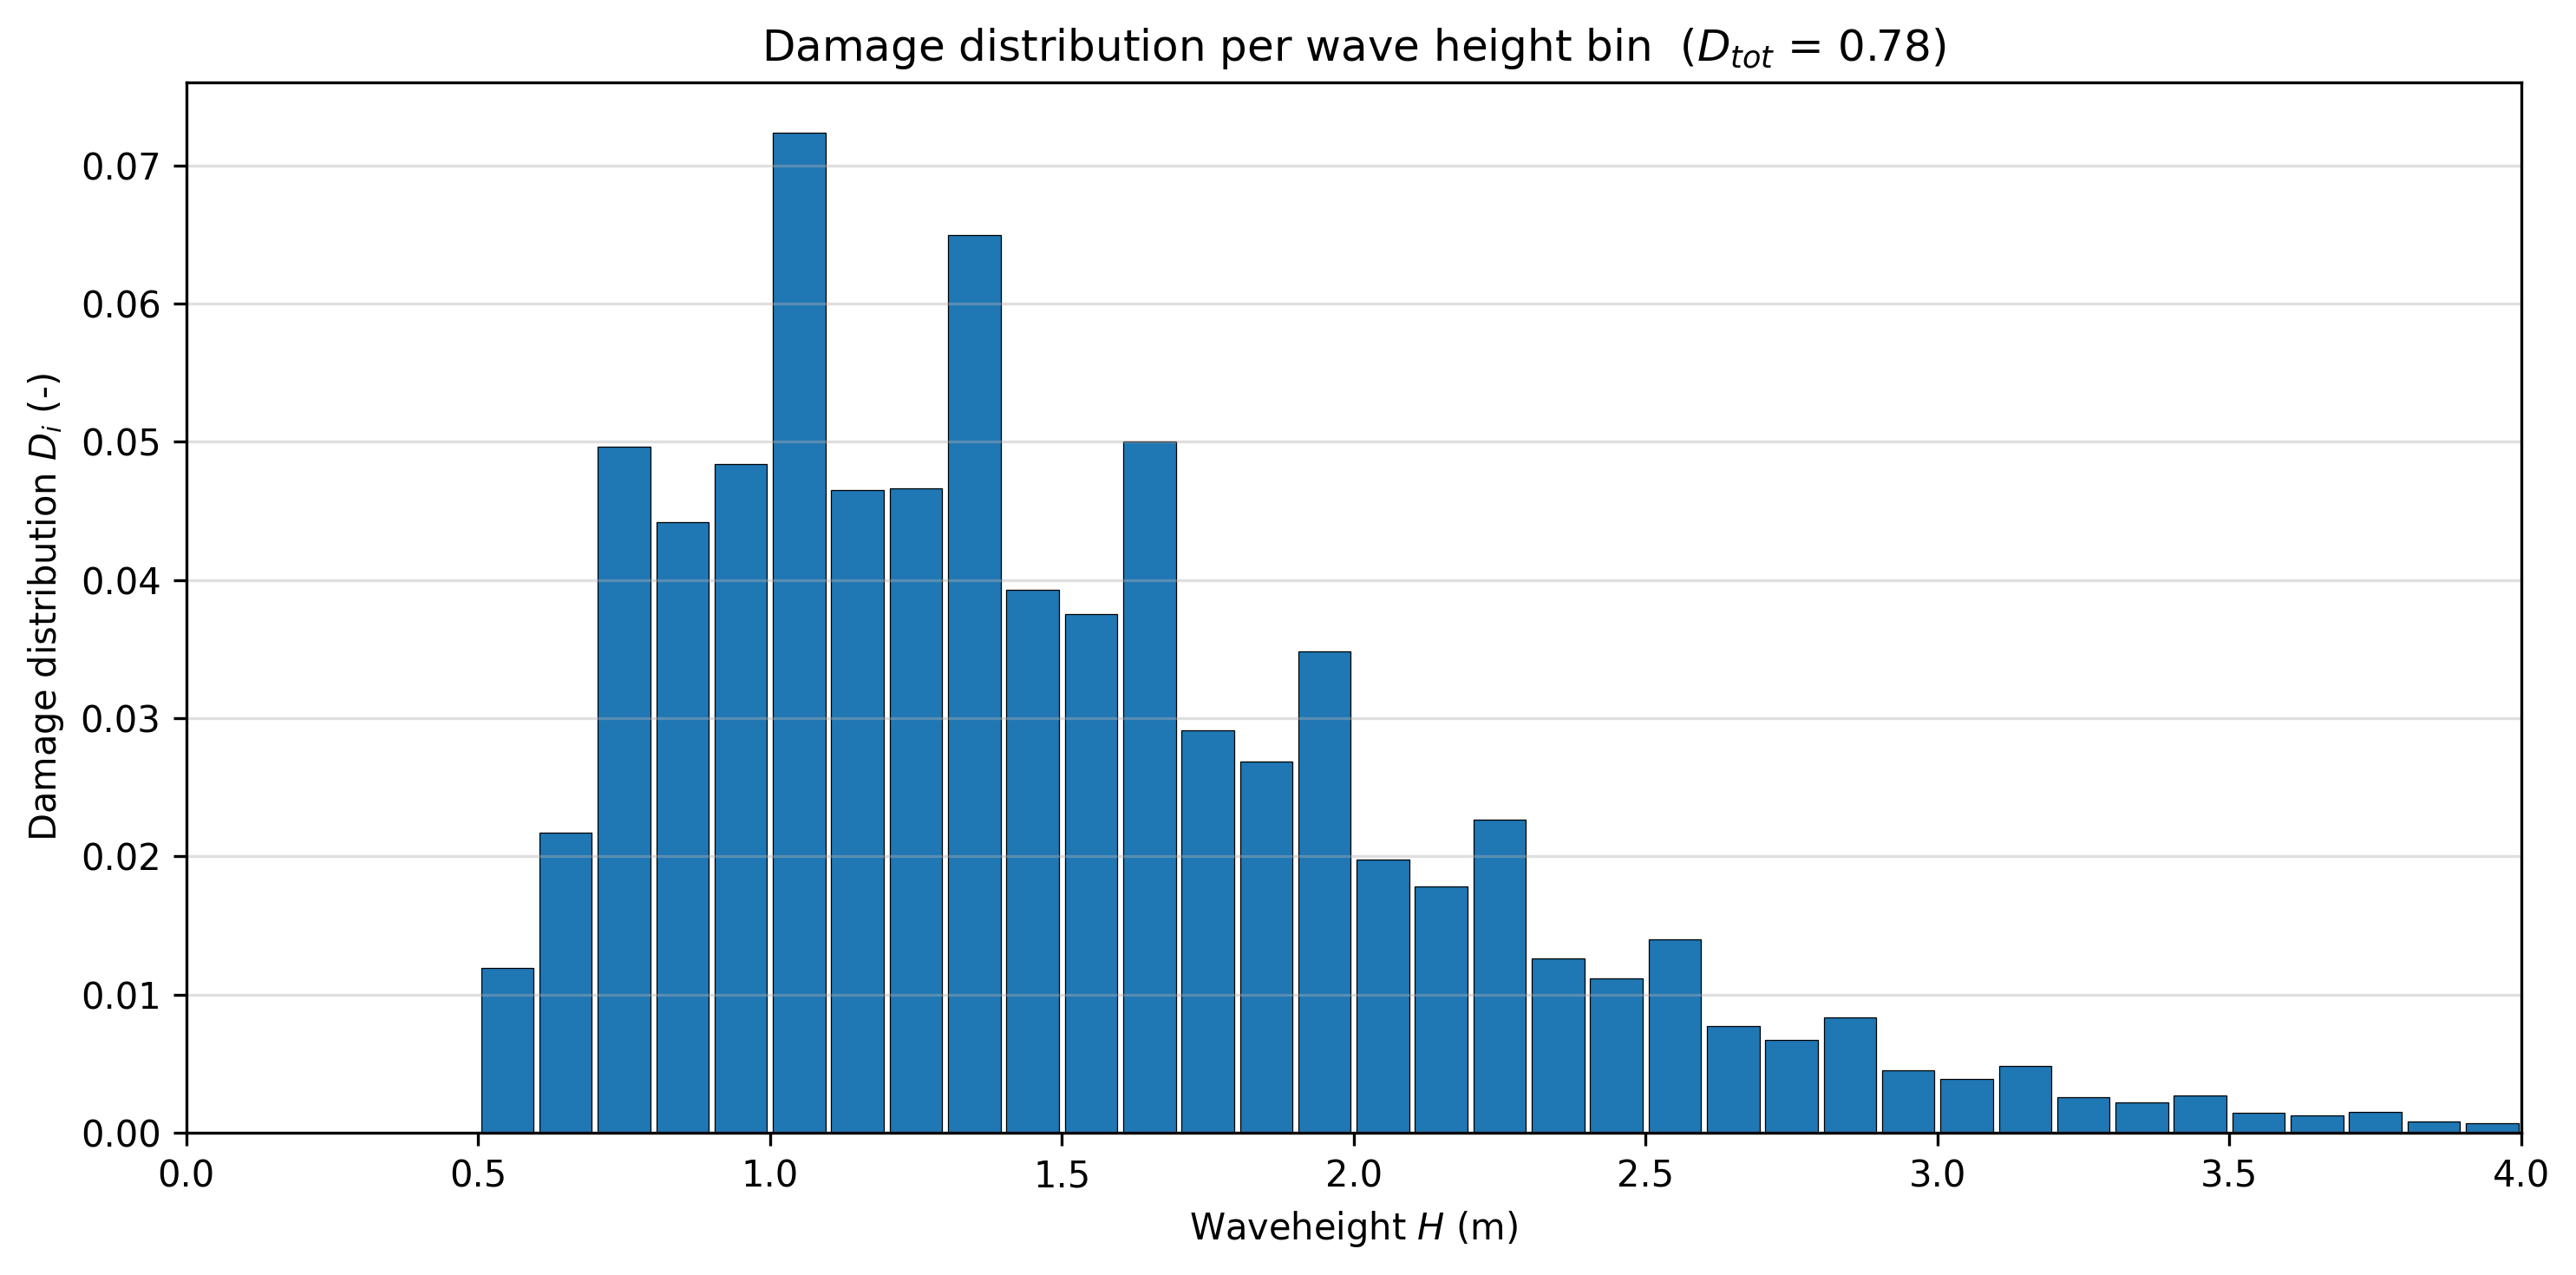

: 

In [ ]:
"""
==========================================================================
METHODE 3 - Vermoeiingsbelasting uit probabilistisch golfklimaat
                     (Nieuwe Waterweg, HR-statistiek)
==========================================================================
Bepaalt het aantal golfwisselingen en de bijbehorende schade (Palmgren-
Miner, FAT 71)


Stappenplan:
  Stap 1  Upper envelope van de HR-data + Weibull-extrapolatie naar T=1 jaar.
  Stap 2  Omzetten van jaarlijkse overschrijdingsfrequentie naar kans per
          sluiting (n_events = 330 sluitingen / 100 jaar = 3.3 /jaar).
  Stap 3  Weibull-fit op de kans per sluiting -> kansdichtheid (pdf) van Hs.
  Stap 4  Discretiseren van de pdf in stormklassen met een CONSTANTE
          representatieve Hs per klasse (klassemidden).
  Stap 5  Lineair verband Tp(Hs) uit de HR-data; Tm = Tp / 1.28.
  Stap 6  Rayleigh-verdeling van individuele golven per stormklasse ->
          aantal golfcycli per fijne golfhoogte-bin, over de levensduur.
  Stap 7  Herbinnen naar blokken van 0.10 m, spanningsrange en toelaatbaar
          aantal wisselingen (FAT 71), Miner-schade per blok en totaal.

==========================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.integrate import quad

EPS = 1e-12

# ==========================================================================
# 0) INVOERPARAMETERS
# ==========================================================================
T_storm       = 35.0     # [uur] stormduur per sluiting (aanname)
N_jaar        = 100.0    # [jaar] ontwerplevensduur
n_sluitingen  = 330      # [-] totaal aantal sluitingen over de levensduur
n_events_jaar = n_sluitingen / N_jaar     # [1/jaar] = 3.3

# --- Discretisatie van de zeegang ---------------------------------------
HS_MIN, HS_MAX = 0.0, 6.0     # [m] bereik van de stormklassen
N_KLASSEN      = 59           # [-] aantal stormklassen
TM_FACTOR      = 1.28         # [-] Tm = Tp / 1.28 (JONSWAP)

# --- FAT 71 S-N-curve (NEN-EN 1993-1-9) ---------------------------------
FAT_CLASS = 80.0     # Delta sigma_C [MPa] bij N = 2e6
N_C, N_D, N_L = 2.0e6, 5.0e6, 1.0e8
M1, M2 = 3.0, 5.0

delta_sigma_D = FAT_CLASS * (N_C / N_D) ** (1.0 / M1)       # 52.31 MPa
delta_sigma_L = delta_sigma_D * (N_D / N_L) ** (1.0 / M2)   # 28.73 MPa

# --- Spanningsgradiënt (Sectie stress_range_lwt) ------------------------
sigma_grad = 70.46    # [MPa/m] spanningsrange per meter golfhoogte


def allowable_cycles_fat71(dsigma):
    """Toelaatbaar aantal wisselingen N_R volgens de bilineaire FAT71-curve."""
    dsigma = np.asarray(dsigma, dtype=float)
    N_R = np.full_like(dsigma, np.inf)

    mask_m3 = dsigma >= delta_sigma_D
    N_R[mask_m3] = N_C * (FAT_CLASS / dsigma[mask_m3]) ** M1

    mask_m5 = (dsigma > delta_sigma_L) & (dsigma < delta_sigma_D)
    N_R[mask_m5] = N_D * (delta_sigma_D / dsigma[mask_m5]) ** M2

    return N_R


# ==========================================================================
# 1) INLEZEN HR-DATA
# ==========================================================================
file_path = (r"C:\Users\saldenh2867\OneDrive - ARCADIS\Documents"
             r"\Python\NieuweWaterweg.xlsx")

waterlevel_col    = "Waterstandsniveau [m+NAP]"
Hs_col            = "Golfhoogte [m]"
Tp_col            = "Piekperiode [s]"
return_period_col = "Terugkeertijd [jaar]"

df = pd.read_excel(file_path)
df["Frequency"] = 1.0 / df[return_period_col]
Freq_col = "Frequency"

df = df[[Freq_col, Hs_col, Tp_col, waterlevel_col, return_period_col]].dropna()

for col in [Freq_col, Hs_col, Tp_col, waterlevel_col, return_period_col]:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False), errors="coerce"
    )

df = df.dropna().sort_values(return_period_col).set_index(return_period_col)


# ==========================================================================
# 2) STAP 1 - UPPER ENVELOPE + EXTRAPOLATIE NAAR T = 1 JAAR
# ==========================================================================
env = (
    df.reset_index()
    .dropna(subset=[Hs_col, Tp_col, waterlevel_col, Freq_col])
    .sort_values(Hs_col)
    .drop_duplicates(subset=Freq_col, keep="last")
    .rename(columns={
        return_period_col: "T_return",
        Freq_col: "Freq per jaar",
        waterlevel_col: "WL_at_Hs_upper",
        Hs_col: "Hs (m)",
        Tp_col: "Tp_at_Hs_upper",
    })
)

env["Freq_mono"] = np.minimum.accumulate(env["Freq per jaar"].to_numpy())

H_env = env["Hs (m)"].to_numpy(float)
p_env = np.clip(env["Freq_mono"].to_numpy(float), EPS, 1 - EPS)


def weibull_exceed_3p(H, a, b, c):
    """3-parameter Weibull-overschrijdingskans: P(H) = exp(-((H-c)/a)^b)."""
    x = np.clip((np.asarray(H, float) - c) / a, 0.0, None)
    return np.exp(-(x ** b))


def resid_envelope(par):
    a, b, c = par
    P_mod = np.clip(weibull_exceed_3p(H_env, a, b, c), EPS, 1 - EPS)
    return np.log(p_env) - np.log(P_mod)


x0     = [np.percentile(H_env, 90), 2.0, H_env.min() - 0.05]
bounds = ([1e-6, 0.3, -1.0], [10 * H_env.max(), 30.0, H_env.min()])
a_env, b_env, c_env = least_squares(
    resid_envelope, x0, bounds=bounds, loss="soft_l1", max_nfev=20000
).x

Hs_T1 = c_env
WL_T1 = np.poly1d(np.polyfit(H_env, env["WL_at_Hs_upper"], 1))(Hs_T1)
Tp_T1 = np.poly1d(np.polyfit(H_env, env["Tp_at_Hs_upper"], 1))(Hs_T1)


# ==========================================================================
# 3) STAP 2 & 3 - KANS PER SLUITING + WEIBULL-FIT OP Hs
# ==========================================================================
env = env.sort_values("Hs (m)").reset_index(drop=True)
env["P_event"] = env["Freq_mono"] / n_events_jaar

fit_mask = env["T_return"] <= 10000
H_fit = env.loc[fit_mask, "Hs (m)"].to_numpy(float)
P_fit = env.loc[fit_mask, "P_event"].to_numpy(float)


def weibull_exceed_2p(H, a, b):
    return np.exp(-(np.asarray(H, float) / a) ** b)


def resid_hs(par):
    a, b = par
    P_mod = np.clip(weibull_exceed_2p(H_fit, a, b), 1e-300, 1.0)
    return np.log(P_fit) - np.log(P_mod)


a_hs, b_hs = least_squares(
    resid_hs, x0=[1.0, 2.0], bounds=([1e-6, 0.3], [50.0, 30.0]),
    loss="soft_l1", max_nfev=20000
).x

print(f"Weibull-fit Hs                        : a = {a_hs:.4f}, b = {b_hs:.4f}")
print(f"Aantal sluitingen per jaar (n_events) : {n_events_jaar:.2f}")


def weibull_pdf_hs(H):
    H = np.asarray(H, float)
    return (b_hs / a_hs) * (H / a_hs) ** (b_hs - 1) * np.exp(-(H / a_hs) ** b_hs)


# ==========================================================================
# 4) STAP 4 - STORMKLASSEN MET CONSTANTE Hs PER KLASSE
# ==========================================================================

klasse_randen  = np.linspace(HS_MIN, HS_MAX, N_KLASSEN + 1)
klasse_midden  = 0.5 * (klasse_randen[:-1] + klasse_randen[1:])
klasse_breedte = np.diff(klasse_randen)

Prob_bin = np.array([
    quad(weibull_pdf_hs, klasse_randen[j], klasse_randen[j + 1])[0]
    for j in range(N_KLASSEN)
])


prob_som = Prob_bin.sum()
print(f"Kansmassa binnen [{HS_MIN}, {HS_MAX}] m       : {prob_som:.6f}")
Prob_bin = Prob_bin / prob_som


T_golfveld = Prob_bin * n_events_jaar * T_storm

df_klassen = pd.DataFrame({
    "Hs_klasse (m)":       klasse_midden,
    "Breedte (m)":         klasse_breedte,
    "Prob (-)":            Prob_bin,
    "Duur per jaar (uur)": T_golfveld,
})

print(f"Totale stormduur per jaar             : {T_golfveld.sum():.1f} uur")
print(f"Totale stormduur over levensduur      : {T_golfveld.sum() * N_jaar:.0f} uur")


# ==========================================================================
# 5) STAP 5 - LINEAIR VERBAND Tp(Hs) EN GEMIDDELDE PERIODE Tm
# ==========================================================================
Hs_data = env["Hs (m)"].to_numpy(float)
Tp_data = env["Tp_at_Hs_upper"].to_numpy(float)

m_tp, q_tp = np.polyfit(Hs_data, Tp_data, 1)


def Tp_lin(H):
    """Piekperiode Tp [s] als functie van Hs, uit regressie op de HR-data."""
    return m_tp * np.asarray(H, float) + q_tp


pred = Tp_lin(Hs_data)
R2 = 1.0 - np.sum((Tp_data - pred) ** 2) / np.sum((Tp_data - Tp_data.mean()) ** 2)
print(f"Regressie Tp = {m_tp:.4f}*Hs + {q_tp:.4f}   (R^2 = {R2:.4f})")

df_klassen["Tp (s)"] = Tp_lin(df_klassen["Hs_klasse (m)"].to_numpy())
df_klassen["Tm (s)"] = df_klassen["Tp (s)"] / TM_FACTOR


# ==========================================================================
# 6) STAP 6 - RAYLEIGH-VERDELING BINNEN ELKE STORMKLASSE
# ==========================================================================
def f_rayleigh(H, Hm0):
    """Rayleigh-kansdichtheid van individuele golfhoogte H binnen zeegang Hm0."""
    return (4.0 * H / Hm0 ** 2) * np.exp(-2.0 * (H / Hm0) ** 2)


H_fijn_randen = np.linspace(HS_MIN, HS_MAX, 141)   # fijne as, stap ~0.043 m
H_fijn_midden = 0.5 * (H_fijn_randen[:-1] + H_fijn_randen[1:])


def prob_rayleigh_bins(Hm0):
    """Kans per fijne golfhoogte-bin binnen een zeegang met significante hoogte Hm0."""
    if Hm0 <= 0:
        return np.zeros(len(H_fijn_randen) - 1)
    return np.array([
        quad(f_rayleigh, H_fijn_randen[i], H_fijn_randen[i + 1], args=(Hm0,))[0]
        for i in range(len(H_fijn_randen) - 1)
    ])


def n_golven_per_uur(Hm0, Tm):
    """Aantal golven per uur binnen elke fijne golfhoogte-bin."""
    N_tot_uur = 3600.0 / Tm
    return prob_rayleigh_bins(Hm0) * N_tot_uur


n_bins = len(H_fijn_randen) - 1
waves_jaar = np.zeros((n_bins, N_KLASSEN))

for j in range(N_KLASSEN):
    Hs_j   = df_klassen.at[j, "Hs_klasse (m)"]
    Tm_j   = df_klassen.at[j, "Tm (s)"]
    duur_j = df_klassen.at[j, "Duur per jaar (uur)"]
    waves_jaar[:, j] = n_golven_per_uur(Hs_j, Tm_j) * duur_j

df_Nwaves = pd.DataFrame(
    waves_jaar,
    columns=[f"Hs={h:.2f}" for h in df_klassen["Hs_klasse (m)"]],
)
df_Nwaves["golfhoogte (m)"] = H_fijn_midden
df_Nwaves = df_Nwaves.set_index("golfhoogte (m)")
df_Nwaves["Nr totaal jaar"]       = df_Nwaves.sum(axis=1)
df_Nwaves["Nr totaal levensduur"] = df_Nwaves["Nr totaal jaar"] * N_jaar

n_cycli_totaal = df_Nwaves["Nr totaal levensduur"].sum()
print(f"\nTotaal aantal golfcycli over levensduur: {n_cycli_totaal:.3e}")


# ==========================================================================
# 7) STAP 7 - HERBINNEN (0.10 m) + MINER-SCHADE
# ==========================================================================
bin_width = 0.10
H_edges = np.arange(HS_MIN, HS_MAX + bin_width, bin_width)
H_mid   = 0.5 * (H_edges[:-1] + H_edges[1:])

H_fine        = df_Nwaves.index.to_numpy()
n_cycles_fine = df_Nwaves["Nr totaal levensduur"].to_numpy()

n_cycles_block = np.array([
    n_cycles_fine[(H_fine >= H_edges[i]) & (H_fine < H_edges[i + 1])].sum()
    for i in range(len(H_mid))
])

dSigma_block = sigma_grad * H_mid
N_R_block    = allowable_cycles_fat71(dSigma_block)

D_block = np.divide(
    n_cycles_block, N_R_block,
    out=np.zeros_like(n_cycles_block),
    where=np.isfinite(N_R_block) & (N_R_block > 0),
)

D_tot        = D_block.sum()
fatigue_life = N_jaar / D_tot if D_tot > 0 else np.inf

df_miner = pd.DataFrame({
    "H_mid (m)":      H_mid,
    "n_i (-)":        n_cycles_block.round(0),
    "dSigma_i (MPa)": dSigma_block.round(2),
    "N_R,i (-)":      N_R_block,
    "D_i (-)":        D_block.round(4),
})

print("\nMiner-schade per golfhoogteblok (bin = 0.10 m):")
print(df_miner[df_miner["D_i (-)"] > 0].to_string(index=False))
print(f"\nD_tot         = {D_tot:.4f}")
print(f"Fatigue life  = {fatigue_life:.1f} jaar")
print("AFGEKEURD" if D_tot > 1.0 else "GOEDGEKEURD")


# ==========================================================================
# 8) CONTROLEPLOTS
# ==========================================================================
H_grid = np.linspace(HS_MIN, 4.0, 400)

# Verdeling van de stormduur over de stormklassen.
# Laat zien dat het grootste deel van de tijd bij lage Hs ligt, ondanks
# de constante Hs binnen elke klasse.
plt.figure(figsize=(10, 5), dpi=300)
plt.bar(df_klassen["Hs_klasse (m)"], df_klassen["Duur per jaar (uur)"],
        width=klasse_breedte * 0.9, edgecolor="k", linewidth=0.3)
plt.xlabel(r"Significant wave hight per storm class $H_{s,j}$ (m)")
plt.ylabel("Duration per year (hour)")
plt.title("Distribution of the storm duration across the storm classes (Method 3)")
plt.grid(True, axis="y", alpha=0.4)
plt.xlim(HS_MIN, 4.0)
plt.tight_layout()
plt.show()

# Schadeverdeling over de spanningsranges
plt.figure(figsize=(10, 5), dpi=300)
plt.bar(H_mid, D_block, width=bin_width * 0.9, edgecolor="k", linewidth=0.3)
plt.xlabel(r"Waveheight $H$ (m)")
plt.ylabel(r"Damage distribution $D_i$ (-)")
plt.title(f"Damage distribution per wave height bin  ($D_{{tot}}$ = {D_tot:.2f})")
plt.grid(True, axis="y", alpha=0.4)
plt.xlim(HS_MIN, 4.0)
plt.tight_layout()
plt.show()


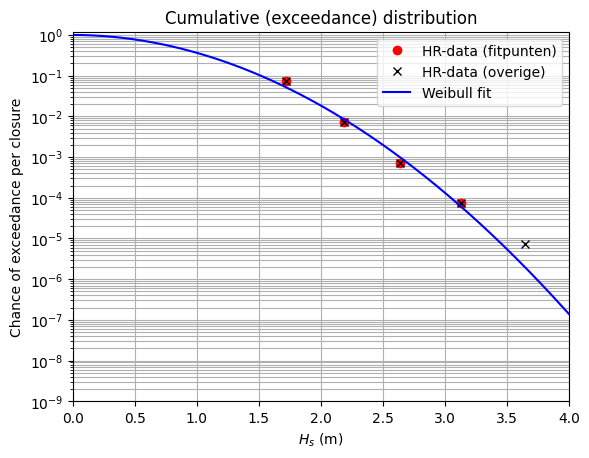

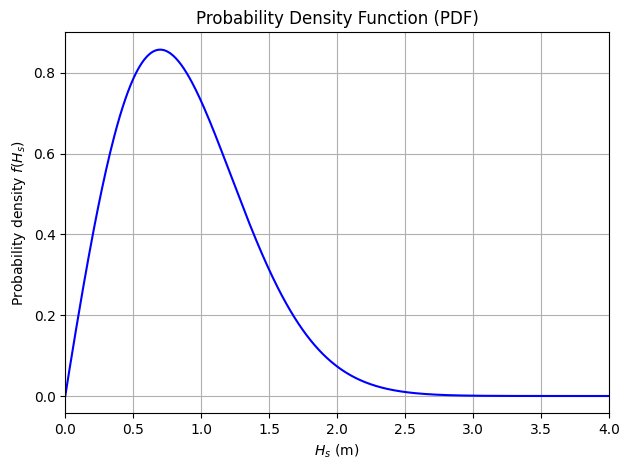

In [ ]:
H_grid = np.linspace(0.0, 4.0, 400)
plt.figure()

plt.plot(H_fit, P_fit, "ro", label="HR-data (fitpunten)")
plt.plot(env["Hs (m)"], env["P_event"], "kx", label="HR-data (overige)")
plt.plot(H_grid, weibull_exceed_2p(H_grid, a_hs, b_hs), "b-", label="Weibull fit")
plt.yscale("log"); plt.ylim(1e-9, 1.2); plt.xlim(0, 4)
plt.grid(True, which="both")
plt.xlabel(r"$H_s$ (m)"); plt.ylabel(r"Chance of exceedance per closure")
plt.title("Cumulative (exceedance) distribution"); plt.legend()

plt.figure()

plt.plot(H_grid, weibull_pdf_hs(H_grid), "b-")
plt.grid(True); plt.xlim(0, 4)
plt.xlabel(r"$H_s$ (m)"); plt.ylabel(r"Probability density $f(H_s)$")
plt.title("Probability Density Function (PDF)")
plt.tight_layout(); plt.show()


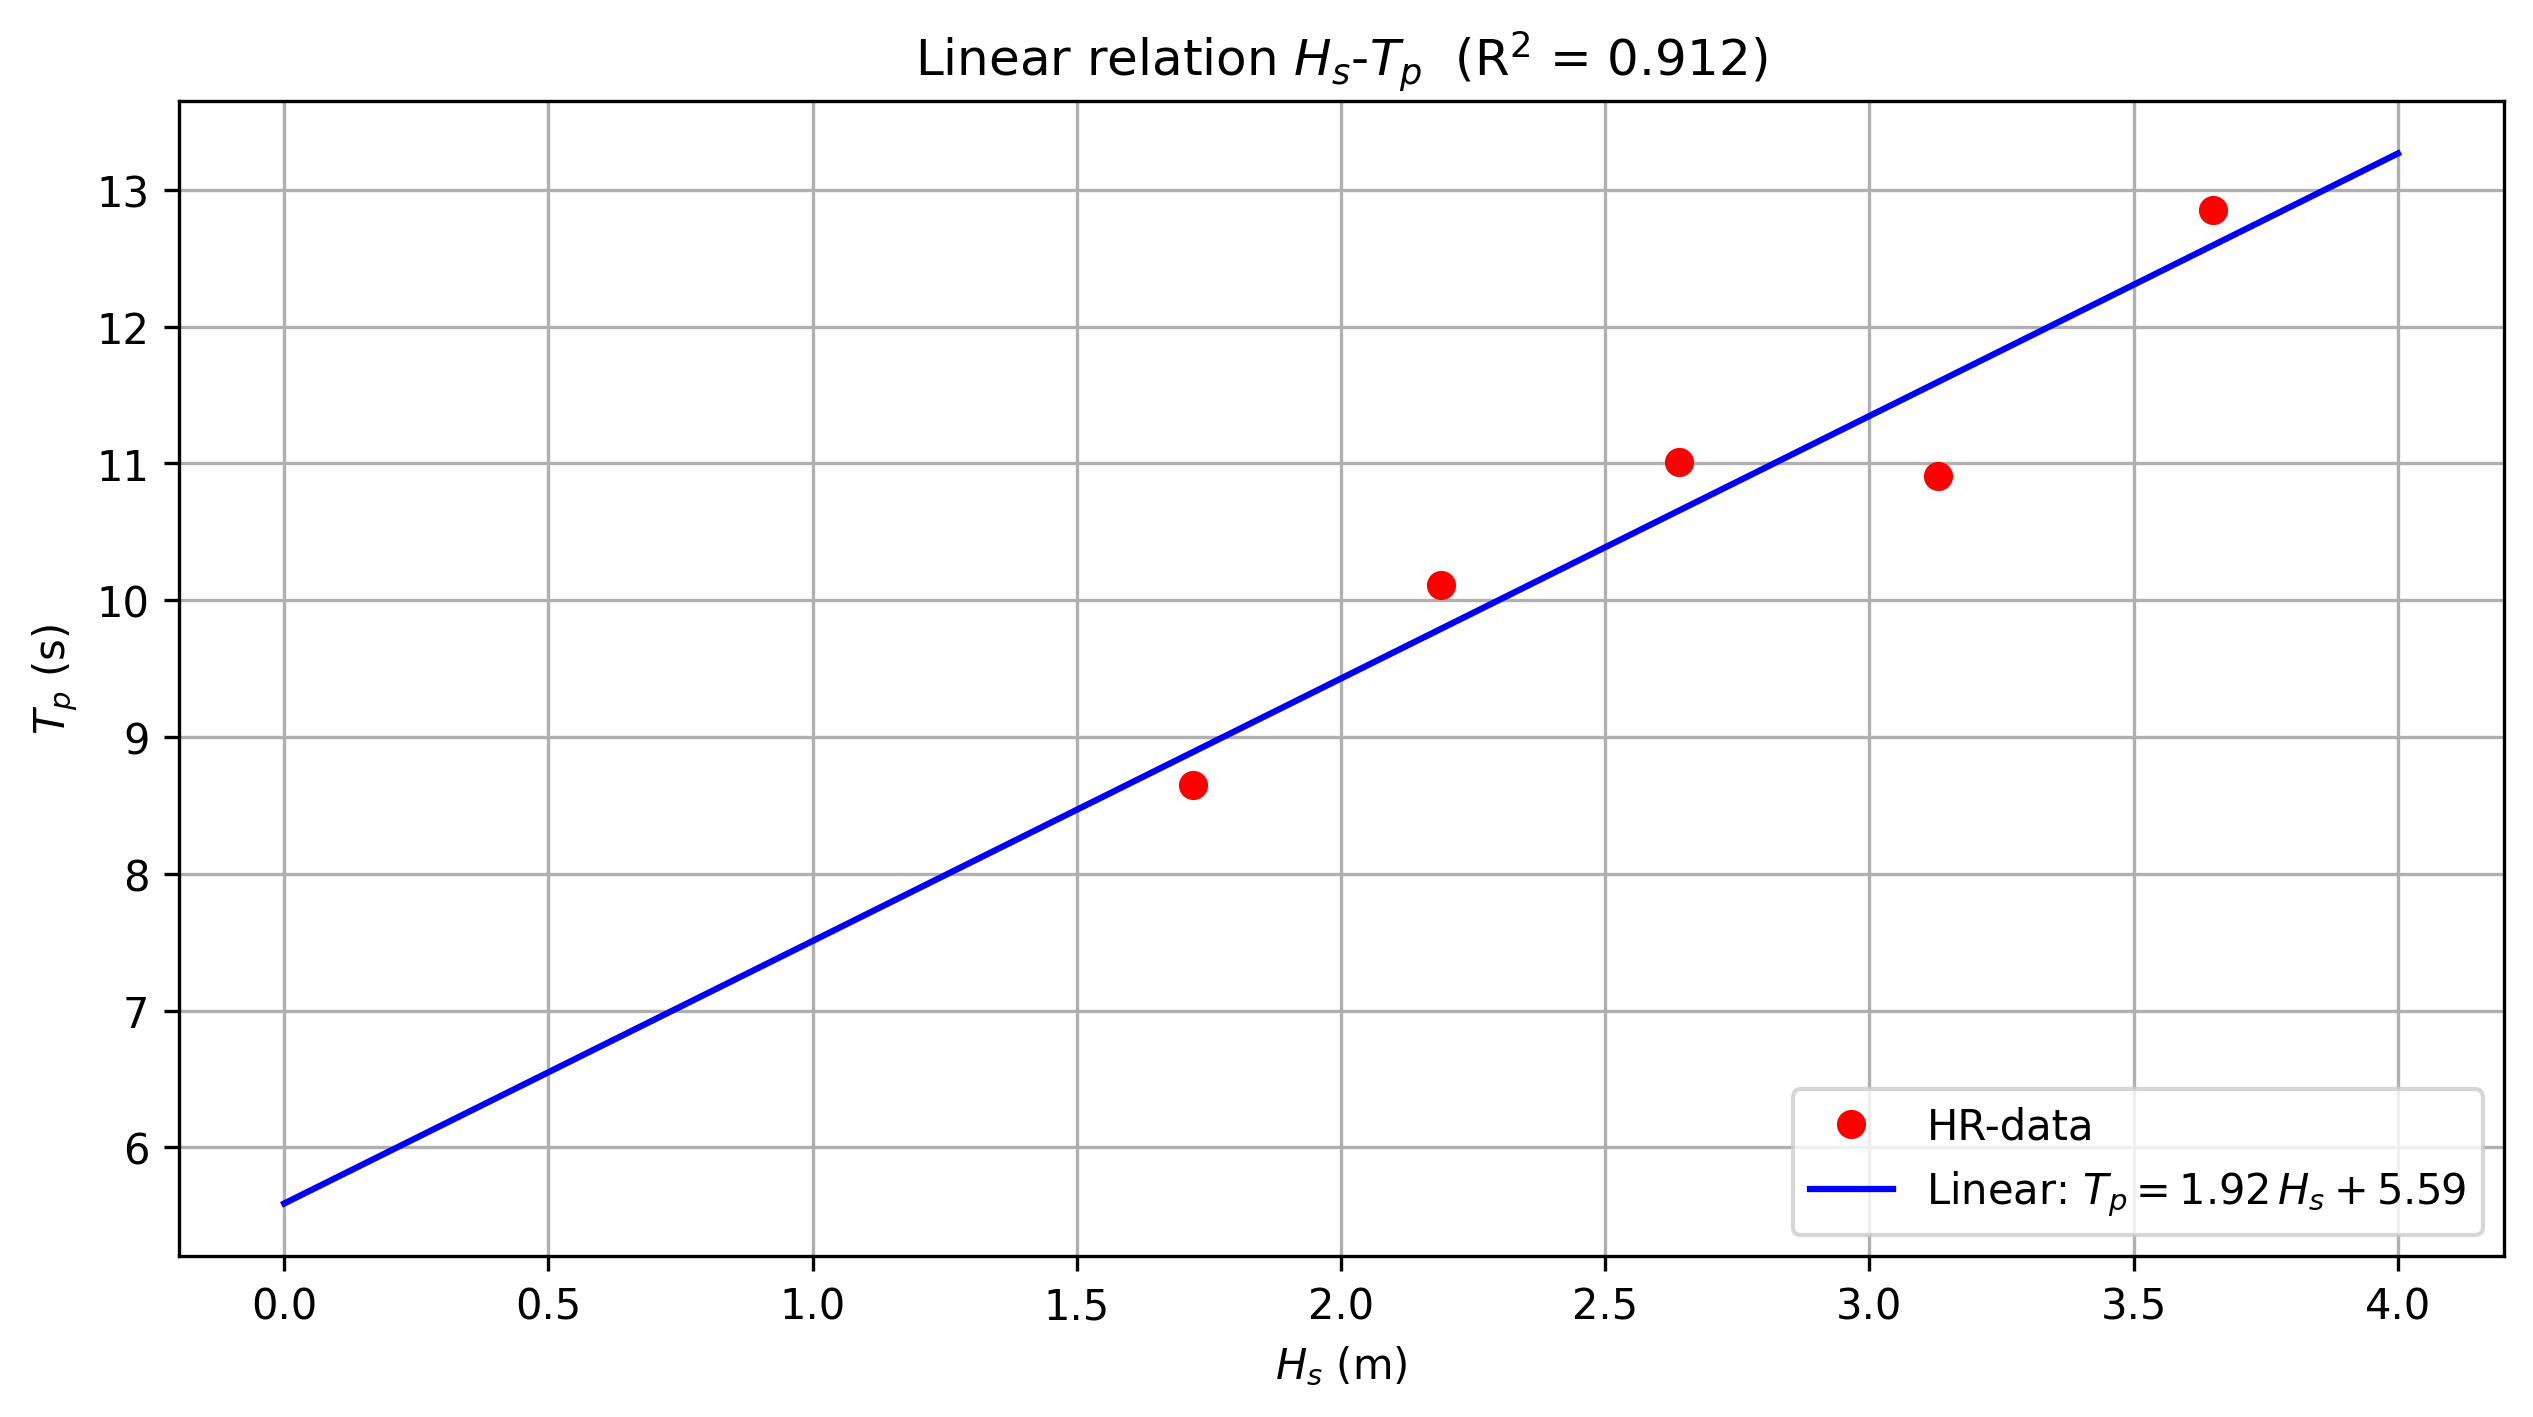

In [ ]:
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(Hs_data, Tp_data, "ro", label="HR-data")
plt.plot(H_grid, Tp_lin(H_grid), "b-", label=f"Linear: $T_p = {m_tp:.2f}\\,H_s + {q_tp:.2f}$")
plt.xlabel(r"$H_s$ (m)"); plt.ylabel(r"$T_p$ (s)")
plt.title(f"Linear relation $H_s$-$T_p$  (R$^2$ = {R2:.3f})")
plt.grid(True); plt.legend(loc="lower right")
plt.show()
